In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

df = pd.read_csv('sample_data.csv', skiprows=2)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head()

,CustomerID,InvoiceDate,Amount
0,1001,2025-01-01,120
1,1002,2025-01-02,300
2,1001,2025-01-10,80
3,1003,2025-01-15,500
4,1004,2025-01-18,60


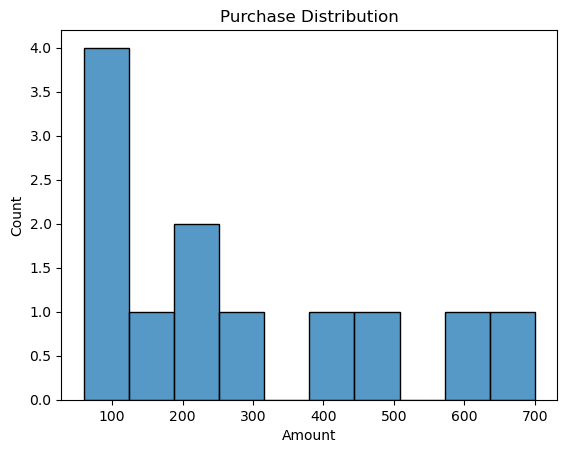

In [23]:
df.describe()

sns.histplot(df['Amount'], bins=10)
plt.title("Purchase Distribution")
plt.show()

In [24]:
reference_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'CustomerID': 'count',
    'Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm

,Recency,Frequency,Monetary
CustomerID,,,
1001,24,3,350
1002,5,3,750
1003,15,2,900
1004,10,2,150
1005,0,2,1300


In [25]:
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm)

rfm

c:\Users\arron\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
1001,24,3,350,1
1002,5,3,750,0
1003,15,2,900,0
1004,10,2,150,1
1005,0,2,1300,2


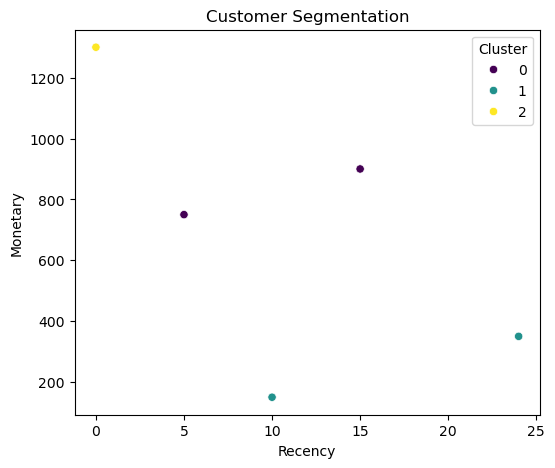

In [26]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x='Recency',
    y='Monetary',
    hue='Cluster',
    data=rfm,
    palette='viridis'
)
plt.title("Customer Segmentation")
plt.show()

In [27]:
for cluster in rfm['Cluster'].unique():
    print(f"\nCluster {cluster}")
    print(rfm[rfm['Cluster']==cluster].mean())


Cluster 1
Recency       17.0
Frequency      2.5
Monetary     250.0
Cluster        1.0
dtype: float64

Cluster 0
Recency       10.0
Frequency      2.5
Monetary     825.0
Cluster        0.0
dtype: float64

Cluster 2
Recency         0.0
Frequency       2.0
Monetary     1300.0
Cluster         2.0
dtype: float64
